# **Сравнительная геномика** | Семинар + ДЗ

**Дисклеймер** \
Предполагается, что вы ознакомились с лекцией перед тем, как открыть этот ноутбук. Здесь не будет подробных объяснений теоретических основ сравнительной геномики, поэтому если они вам не знакомы, то первым делом изучите лекционный материал

**ПОЛИТИКА В ОТНОШЕНИИ ГПТ** \
Я не психопат (во всяком случае не настолько), чтобы с серьезным лицом запрещать вам использовать ллмки. Однако, если вы делаете это крайне безответственно, то будут санкции в виде снижения оценки. Например, однажды в Сколтехе студентка написала функцию определения $R^2$ в ячейке под той, в которой показано, как вызвать подсчет этой метрики в phylokrr одной строкой. Лицо мое представили

**ЕЩЕ ОДНО ПРЕДУПРЕЖДЕНИЕ! Не запускайте бездумно все ячейки подряд, как бы сильно не хотелось. Спамить шифт+энтер здесь не получится...**

## Настройка конда среды и установка нужных библиотек

Я локально пошел крутить, чтобы на 12 CPU apple гонять. Поэтому убираю лишние настройки окружения.

In [1]:
!pip install -q phylokrr biopython 2>&1 | tail -3

!hyphy --version

HYPHY 2.5.100(MP) for Darwin on arm64 ARM Neon SIMD zlib (v1.3.2)


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
import json

import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (12, 8)

In [3]:
!git clone https://github.com/Malaevleo/cba_comp_age_hw.git

Cloning into 'cba_comp_age_hw'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 49 (delta 16), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 49.53 KiB | 905.00 KiB/s, done.
Resolving deltas: 100% (16/16), done.


## Вступление

В этом ноутбуке мы сфокусируемся на отряде *Chiroptera* (Рукокрылые). Многие его представители живут удивительно долго. Например, *Myotis brandtii* (Ночница Брандта) может жить 40+ лет при весе всего в 7 грамм. Очень интересно узнать, какие генетические адаптации могут стоять за таким биологическим феноменом

Дерево из TimeTree:
![image.png](_...)

Добавим значения LQ из датабазы AnnAge и разделим летучих мышей на 3 категории в зависимости от LQ.

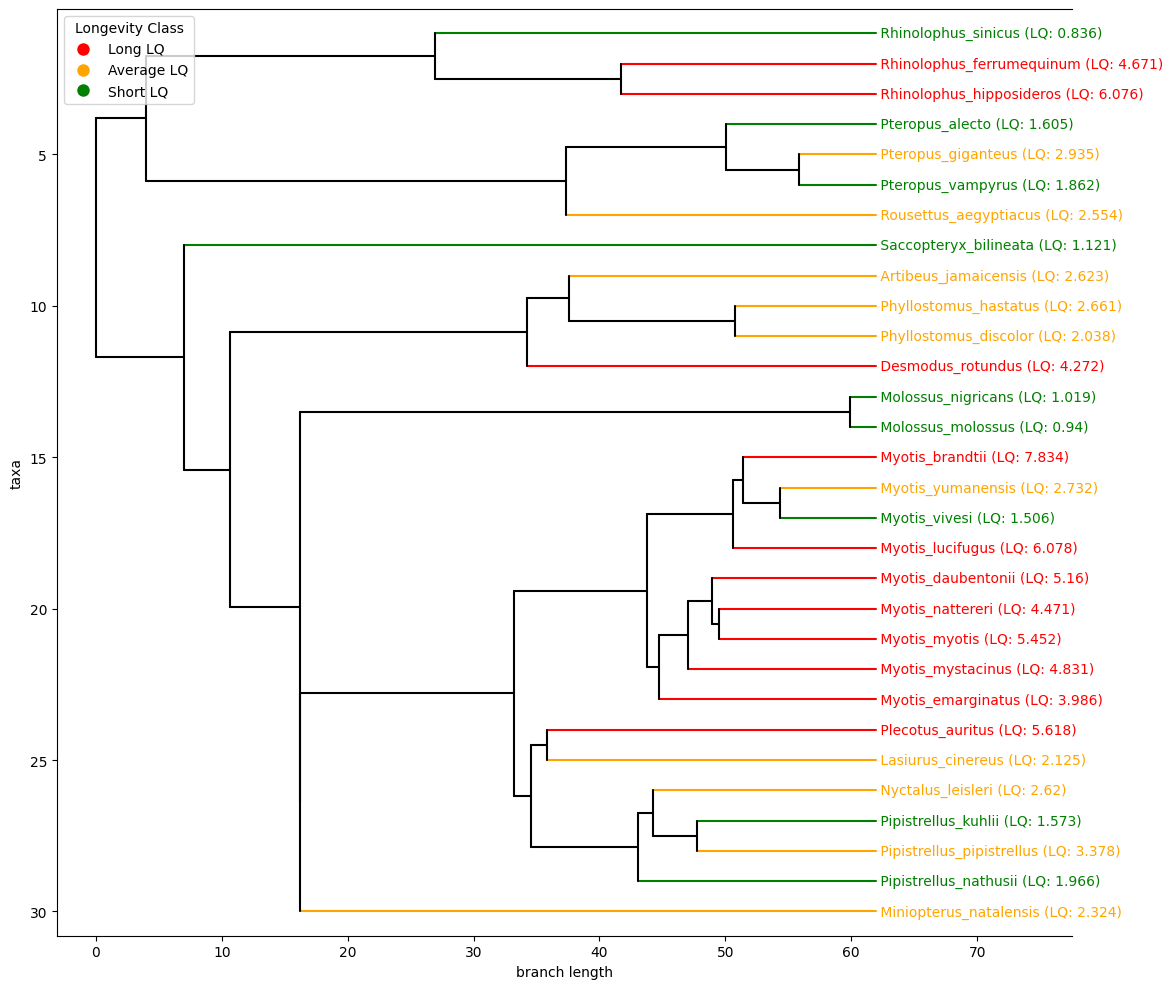

Всего у нас 30 видов, что, конечно, не так уж и много, но вполне неплохо для одной клады. Особенно интересно разнообразие по продолжительности жизни, нормализованной по массе.

Проведем анализ, взяв за основу следующий пайплайн:

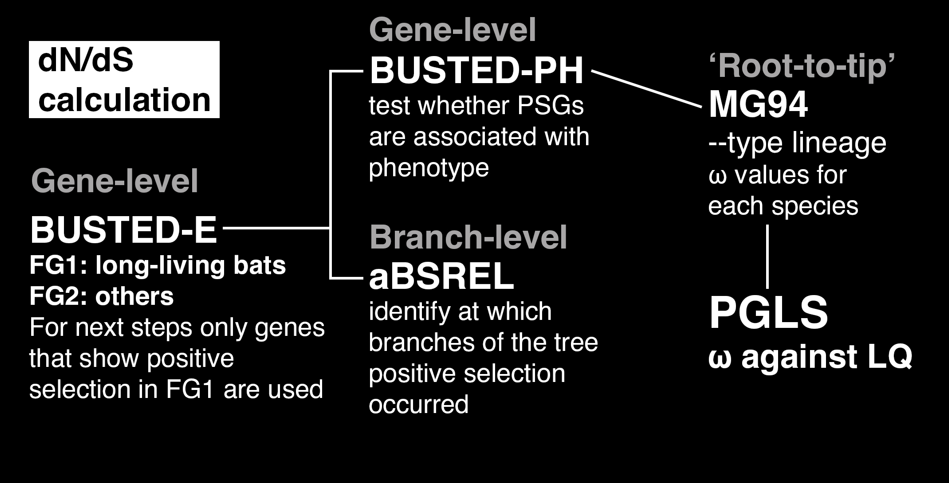

Он включает в себя почти все, что обсуждалось на лекции, а также позволяет оценить отбор на уровне индивидуальных ветвей и оценить ассоциацию dN/dS с любой количественной метрикой (в нашем случае LQ).

## Данные

Для каждого гена у нас есть и MSA, и дерево.

**MMP25:** \
mmp25_aln.fasta -> MSA \
mmp25_tree.nwk -> phylogenetic tree \
Аналогично для других генов (CLEC14A, POLG).

MMP25 - матрисомная металлпротеаза, являющаяся важным компонентом внеклеточного матрикса.

## dN/dS

### BUSTED

Создадим функцию, запускающую BUSTED-E

In [4]:
def run_busted(alignment, tree, branches="Foreground"):
    os.makedirs("./results", exist_ok=True)
    gene = os.path.basename(alignment).split("_")[0]
    out_json = f"./results/{gene}_{branches}_res.json"
    log_file = f"./results/{gene}_{branches}_log.txt"

    # команда для баша
    # мы запускаем хайфай через нашу конда среду
    cmd = [
        "hyphy", f"CPU={os.cpu_count()}", "busted", # определяет, какой тул будет использован
        "--alignment", alignment,
        "--tree", tree,
        "--branches", branches,
        "--error-sink", "Yes", # это включает BUSTED-E
        "--output", out_json,
    ]

    with open(log_file, "w") as log:
        subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)

    print(f"Done: {out_json}")

Наша функция `run_busted` использует 3 аргумента:

1.   `align` MSA
2.   `tree` дерево
3. `branches` какая группа ветвей тестируется на положительный отбор. Модель с 3 $\omega$ классами фитится на эти ветви



Проанализируем MMP25, используя нашу функцию:

In [5]:
run_busted("./cba_comp_age_hw/mmp25_aln.fasta","./cba_comp_age_hw/mmp25_tree.nwk","Foreground")

Done: ./results/mmp25_Foreground_res.json


В среднем на прогон уходит от 5 до 40 минут в случае большого количества видов

*Можно прогнать BUSTED-E и через одну длинную команду, что для биоинформатики вообще-то классика...*

Давайте посмотрим на результаты. Они сохранены в json файле и еще в txt с логом.

Можем визуализировать json:

In [6]:
def check_busted_results(path="results/mmp25_Foreground_res.json"):
    with open(path) as f:
        data = json.load(f)

    lrt = data["test results"]["LRT"]
    p_value = data["test results"]["p-value"]
    logL_unconstrained = data["fits"]["Unconstrained model"]["Log Likelihood"]
    logL_constrained = data["fits"]["Constrained model"]["Log Likelihood"]

    print(f"LRT statistic: {lrt:.4f}")
    print(f"P-value: {p_value:.4g}")
    print(f"Unconstrained logL: {logL_unconstrained:.4f}")
    print(f"Constrained logL: {logL_constrained:.4f}")

check_busted_results(path="results/mmp25_Foreground_res.json")

LRT statistic: 5.5799
P-value: 0.03071
Unconstrained logL: -7930.8485
Constrained logL: -7933.6384


Как мы видим, этот ген претерпевает положительный отбор. Для более детального анализа перейдем к следующим стадиям пайплайна.

ДЛЯ НАСТОЯЩИХ ЦЕНИТЕЛЕЙ СРАВНИТЕЛЬНОЙ ГЕНОМИКИ: \
*Результаты могут слегка разниться в зависимости от фита модели. Самый лучший способ получить абсолютно воспроизводимый результат заключается в предварительном фите обычного BUSTED, извлечения параметров и уже дальнейшего запуска BUSTED-E.*

Можно посмотреть, есть ли отбор на фоновых ветвях.

In [7]:
run_busted("./cba_comp_age_hw/mmp25_aln.fasta","./cba_comp_age_hw/mmp25_tree.nwk","Background")

Done: ./results/mmp25_Background_res.json


**Давайте изучим, на каких конкретно ветвях дерева мог возникнуть положительный отбор**

### aBSREL

В этом методе мы не указываем, какие ветви хотим смотреть, потому что он должен анализировать все.

In [ ]:
def run_absrel(align, tree):
    os.makedirs("./results", exist_ok=True)
    gene = os.path.basename(align).split("_")[0]
    out_json = f"./results/{gene}_absrel_res.json"
    log_file = f"./results/{gene}_absrel_log.txt"

    cmd = [
        "hyphy", f"CPU={os.cpu_count()}", "absrel",
        "--alignment", align,
        "--tree", tree,
        "--output", out_json
    ]

    with open(log_file, "w") as log:
        subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)

    print(f"✅ Done: {out_json}")

In [9]:
run_absrel("./cba_comp_age_hw/mmp25_aln.fasta","./cba_comp_age_hw/mmp25_tree.nwk")

✅ Done: ./results/mmp25_absrel_res.json


Примерно 10 минут

Изучим результаты:

In [10]:
with open("results/mmp25_absrel_res.json") as f:
    data = json.load(f)

pos_test_res = data["test results"]["positive test results"]

print(f"Positive test results: {pos_test_res:f}")

Positive test results: 2.000000


Ветви с положительном отбором нашлись. Давайте посмотрим, какие это мыши:

In [58]:
def check_absrel_results(path="results/mmp25_absrel_res.json"):
    with open(path) as f:
        data = json.load(f)


    pos_test_res = data["test results"]["positive test results"]


    print(f"Positive test results: {pos_test_res:f}")

    branches = data["branch attributes"]["0"]

    print("Branches under episodic positive selection:\n")

    for bname, attrs in branches.items():
        pval = attrs.get("Corrected P-value", 1)
        if pval < 0.05:
            LRT = attrs.get("LRT", None)
            rate_dist = attrs.get("Rate Distributions", [])
            omega, prop = None, None
            if len(rate_dist) > 1:  # 2+ classes → second one is usually ω>1
                omega, prop = rate_dist[-1]
            elif rate_dist:         # only one class (impossible situation basically)
                omega, prop = rate_dist[0]

            print(f"{bname:25s}  p={pval:.2e}  LRT={LRT:.2f}  ω={omega:.2f}  prop={prop:.2%}")

check_absrel_results(path="results/mmp25_absrel_res.json")

Positive test results: 2.000000
Branches under episodic positive selection:

mbXP_014392669_1           p=0.00e+00  LRT=78.79  ω=253.75  prop=4.08%
mlXP_006090523_1           p=9.85e-03  LRT=15.05  ω=2222.54  prop=0.26%


*Myotis brandtii* и *Myotis lucifugus* демонстируют положительный отбор. Это одни из самых долгоживущих летучих мышей в природе, поэтому это весьма закономерно.

## MG94 root-to-tip dN/dS calculation

MG94 с опцией "lineage" используется для расчета dN/dS от корня до вершины (листа) дерева. Корень здесь - общий предок всех рукокрылых. \
Увы, запуск root-to-tip расчета требует неких танцев с бубном, поскольку для этого нужно загружать дополнительный набор скриптов hyphy-analyses и надеяться, что патчи на сам hyphy ничего не сломали.


In [12]:
!git clone --depth 1 https://github.com/veg/hyphy-analyses.git

fatal: destination path 'hyphy-analyses' already exists and is not an empty directory.


In [27]:
!hyphy ./hyphy-analyses/FitMG94/FitMG94.bf --help


Available analysis command line options
---------------------------------------
Use --option VALUE syntax to invoke
If a [reqired] option is not provided on the command line, the analysis will prompt for its value
[conditionally required] options may or not be required based on the values of other options

rooted
	Accept rooted trees
	default value: No

type
	Model type: 
        - global (single dN/dS for all branches) 
        - local (separate dN/dS) 
        - partitioned (separate dN/dS for user-defined groups)
        - lineage (separate dN/dS for each tip's lineage)
	default value: terms.global [computed at run time]
	applies to: Model Type

code
	Which genetic code should be used
	default value: Universal

alignment [required]
	An in-frame codon alignment in one of the formats supported by HyPhy

tree [conditionally required]
	A phylogenetic tree
	applies to: Please select a tree file for the data:

frequencies
	Equilibrium frequency estimator
	default value: CF3x4

lrt
	Perfo

Если показывает гайд на MG94 -> все хорошо.

In [ ]:
def run_mg94(align, tree):
    os.makedirs("./results", exist_ok=True)
    gene = os.path.basename(align).split("_")[0]
    out_json = f"./results/{gene}_mg94_res.json"
    log_file = f"./results/{gene}_mg94_log.txt"

    cmd = [
        "hyphy", f"CPU={os.cpu_count()}", "hyphy-analyses/FitMG94/FitMG94.bf",
        "--alignment", align,
        "--tree", tree,
        "--type", "lineage",
        "--output", out_json
    ]

    with open(log_file, "w") as log:
        subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)
    print(f"✅ Done: {out_json}")

In [32]:
run_mg94("./cba_comp_age_hw/mmp25_aln.fasta", "./cba_comp_age_hw/mmp25_tree.nwk")

✅ Done: ./results/mmp25_mg94_res.json


Примерно 10 мин

*В одну строку:*

Создадим csv файл, который потом будем использовать для PGLS

In [33]:
d=json.load(open("./results/mmp25_mg94_res.json"))["branch attributes"]["0"]
pd.DataFrame([{"node":k,"lineage_dNdS":v["Lineage dN/dS"]}for k,v in d.items()if"Lineage dN/dS"in v]).to_csv("mmp25_dnds.csv",index=False)


In [35]:
df = pd.read_csv("mmp25_dnds.csv")
df.head()

,node,lineage_dNdS
0,ajXP_037010567_1,0.157670
1,drXP_024409158_2,0.181771
2,lcg18142_t1,0.193254
3,mag18797_t1,0.221696
4,mbXP_014392669_1,0.261361


Добавим в датафрейм названия видов и LQ, потому что это потребуется для PGLS

In [36]:
REF = {
    'aj': {'Species': 'Artibeus_jamaicensis',      'LQ': 2.6},
    'dr': {'Species': 'Desmodus_rotundus',         'LQ': 4.3},
    'lc': {'Species': 'Lasiurus_cinereus',         'LQ': 2.1},
    'ma': {'Species': 'Myotis_nattereri',          'LQ': 4.5},
    'mb': {'Species': 'Myotis_brandtii',           'LQ': 7.8},
    'md': {'Species': 'Myotis_daubentonii',        'LQ': 5.2},
    'me': {'Species': 'Myotis_emarginatus',        'LQ': 4.0},
    'mi': {'Species': 'Molossus_nigricans',        'LQ': 1.0},
    'ml': {'Species': 'Myotis_lucifugus',          'LQ': 6.0},
    'mm': {'Species': 'Myotis_myotis',             'LQ': 5.5},
    'mn': {'Species': 'Miniopterus_natalensis',    'LQ': 2.3},
    'mo': {'Species': 'Molossus_molossus',         'LQ': 0.9},
    'ms': {'Species': 'Myotis_mystacinus',         'LQ': 4.8},
    'mv': {'Species': 'Myotis_vivesi',             'LQ': 1.5},
    'my': {'Species': 'Myotis_yumanensis',         'LQ': 2.7},
    'nl': {'Species': 'Nyctalus_leisleri',         'LQ': 2.6},
    'pa': {'Species': 'Pteropus_alecto',           'LQ': 1.6},
    'pd': {'Species': 'Phyllostomus_discolor',     'LQ': 2.0},
    'pg': {'Species': 'Pteropus_giganteus',        'LQ': 2.9},
    'ph': {'Species': 'Phyllostomus_hastatus',     'LQ': 2.7},
    'pk': {'Species': 'Pipistrellus_kuhlii',       'LQ': 1.6},
    'pn': {'Species': 'Pipistrellus_nathusii',     'LQ': 2.0},
    'pp': {'Species': 'Pipistrellus_pipistrellus', 'LQ': 3.4},
    'pu': {'Species': 'Plecotus_auritus',          'LQ': 5.6},
    'pv': {'Species': 'Pteropus_vampyrus',         'LQ': 1.9},
    'ra': {'Species': 'Rousettus_aegyptiacus',     'LQ': 2.6},
    'rf': {'Species': 'Rhinolophus_ferrumequinum', 'LQ': 4.7},
    'rh': {'Species': 'Rhinolophus_hipposideros',  'LQ': 6.1},
    'rs': {'Species': 'Rhinolophus_sinicus',       'LQ': 0.8},
    'sb': {'Species': 'Saccopteryx_bilineata',     'LQ': 1.1},
}


In [37]:
code = df["node"].str[:2].str.lower()
df["Species"] = code.map(lambda c: REF.get(c, {}).get("Species"))
df["LQ"] = code.map(lambda c: REF.get(c, {}).get("LQ"))

df.to_csv("mmp25_dnds_LQ.csv", index=False)
print(df.head())


               node  lineage_dNdS               Species   LQ
0  ajXP_037010567_1      0.157670  Artibeus_jamaicensis  2.6
1  drXP_024409158_2      0.181771     Desmodus_rotundus  4.3
2       lcg18142_t1      0.193254     Lasiurus_cinereus  2.1
3       mag18797_t1      0.221696      Myotis_nattereri  4.5
4  mbXP_014392669_1      0.261361       Myotis_brandtii  7.8


Давайте посмотрим, отличаются ли мыши из рода *Myotis* от остальных

group
Myotis    0.228178
Other     0.177206
Name: lineage_dNdS, dtype: float64


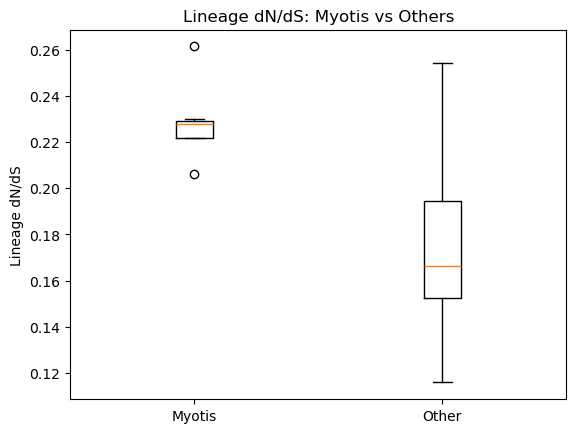

In [39]:
myotis_dict = {"mb", "ml", "md", "mm", "me", "ma", "my"}
df["code"] = df["node"].str[:2].str.lower()
df["group"] = df["code"].isin(myotis_dict).map({True: "Myotis", False: "Other"})

print(df.groupby("group")["lineage_dNdS"].mean())

plt.figure()
plt.boxplot(
    [df.loc[df["group"]=="Myotis","lineage_dNdS"],
     df.loc[df["group"]=="Other","lineage_dNdS"]],
    labels=["Myotis","Other"],
    showmeans=False
)
plt.ylabel("Lineage dN/dS")
plt.title("Lineage dN/dS: Myotis vs Others")
plt.show()

## PGLS

К сожалению тут удобнее всего перезапустить среду колаба, чтобы избежать конфликтов при установке пакета phylokrr. Понимаю, что звучит ужасно, но это действительно наиболее быстрый способ продолжить работу. \
**Обязательно предварительно сохраните csv файлы с результатами dN/dS анализа!**

Я сделал так, чтобы не пришлось перезапускать!

In [57]:
from Bio import Phylo
from phylokrr.dataio import read_data
from phylokrr.utils import weight_data
from phylokrr.kernels import KRR
from phylokrr.utils import PGLS
from phylokrr.utils import k_fold_cv_random

Для PGLS в phylokrr нам нужен отдельный датафрейм с независимыми переменными и таргетом, список видов и дерево. Но есть нюанс: внутренние ноды (промежуточные) не должны быть подписаны вообще никак. Почему так сделано? Потому что автор библиотеки - сверхчеловек по Ницше


In [42]:
df_modified = df.drop(["node", "Species"], axis=1)
df_modified.to_csv('test_data.csv', index=False, header=False)
df_modified.head()

,lineage_dNdS,LQ
0,0.157670,2.6
1,0.181771,4.3
2,0.193254,2.1
3,0.221696,4.5
4,0.261361,7.8


In [43]:
species_names = df['Species']
species_names.to_csv('species.txt', index= False, header=None)
species_names.head()

0    Artibeus_jamaicensis
1       Desmodus_rotundus
2       Lasiurus_cinereus
3        Myotis_nattereri
4         Myotis_brandtii
Name: Species, dtype: str

In [46]:
tree_file = "./cba_comp_age_hw/pgls_tree.txt"

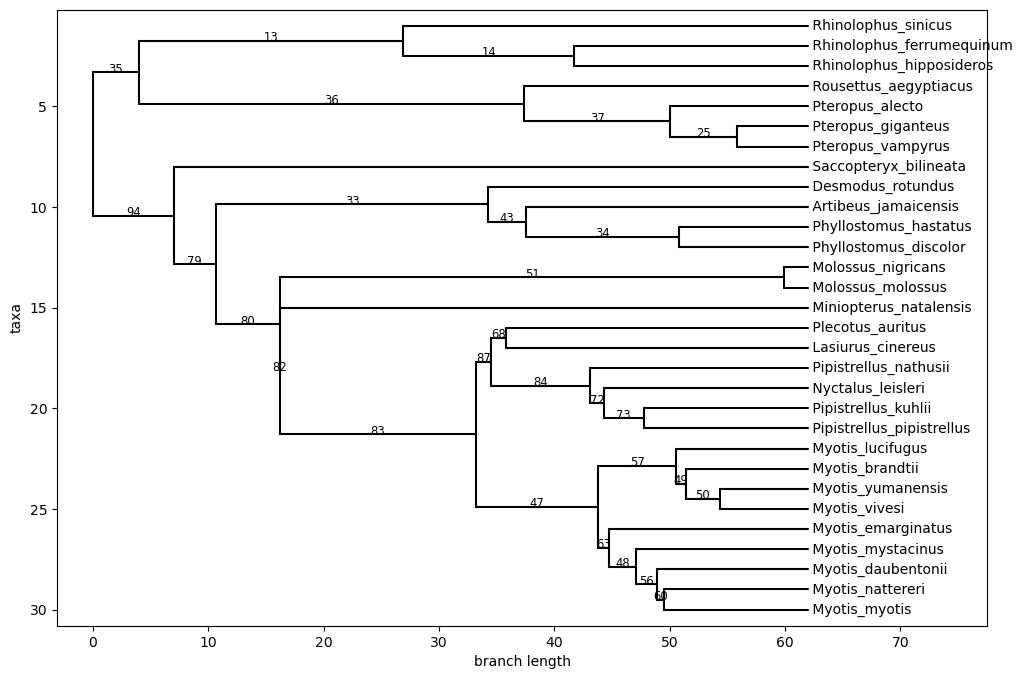

In [56]:
tree = Phylo.read(tree_file, "newick")
tree.ladderize()
Phylo.draw(tree)

Люблю ASCII арт, давайте посмотрим на наше дерево вот так:

In [ ]:
Phylo.draw_ascii(tree)

                       ___________________________ Rhinolophus_sinicus
     _________________|
    |                 |           ________________ Rhinolophus_ferrumequinum
    |                 |__________|
  __|                            |________________ Rhinolophus_hipposideros
 |  |
 |  |                          ___________________ Rousettus_aegyptiacus
 |  |_________________________|
 |                            |          _________ Pteropus_alecto
 |                            |_________|
 |                                      |     ____ Pteropus_giganteus
_|                                      |____|
 |                                           |____ Pteropus_vampyrus
 |
 |     ___________________________________________ Saccopteryx_bilineata
 |    |
 |    |                      _____________________ Desmodus_rotundus
 |    |   __________________|
 |____|  |                  |  ___________________ Artibeus_jamaicensis
      |  |                  |_|
      |  |              

phylokrr может "взвешивать" данные. Это необходимо для использования нелинейного ядра. В нашем случае можно обойтись и без этого.


X shape:  (30, 1)
numeric columns:  [0]
categorical columns:  []
30 names from data, 30 from tree, 30 intersect


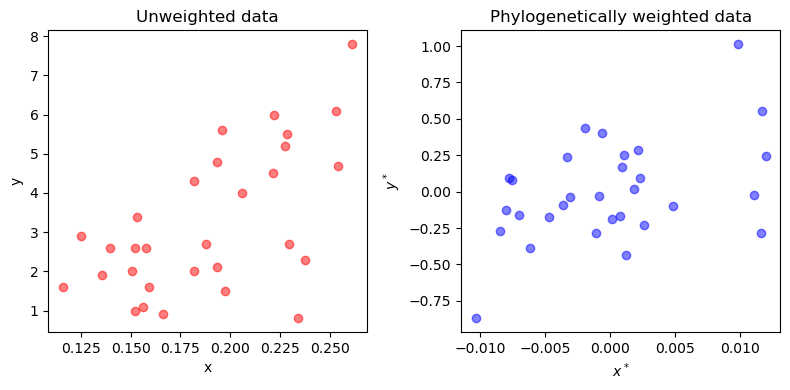

In [95]:
data_file = "test_data.csv"
data_file_spps = "species.txt"

X_uw_uc, y_uw_uc, vcv = read_data(tree_file, data_file, data_file_spps, y_col = 1, # таргет
                                  delimiter = ',', verbose = True)

X_w, y_w = weight_data(X_uw_uc, y_uw_uc, vcv, use_sd = False)

np.random.seed(12038)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].scatter(X_uw_uc, y_uw_uc, color = 'red', alpha=0.5, )
axs[0].set_title('Unweighted data')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[1].scatter(X_w, y_w, color = 'blue', alpha=0.5, )
axs[1].set_title('Phylogenetically weighted data')
axs[1].set_xlabel('$x^*$')
axs[1].set_ylabel('$y^*$')
plt.tight_layout()

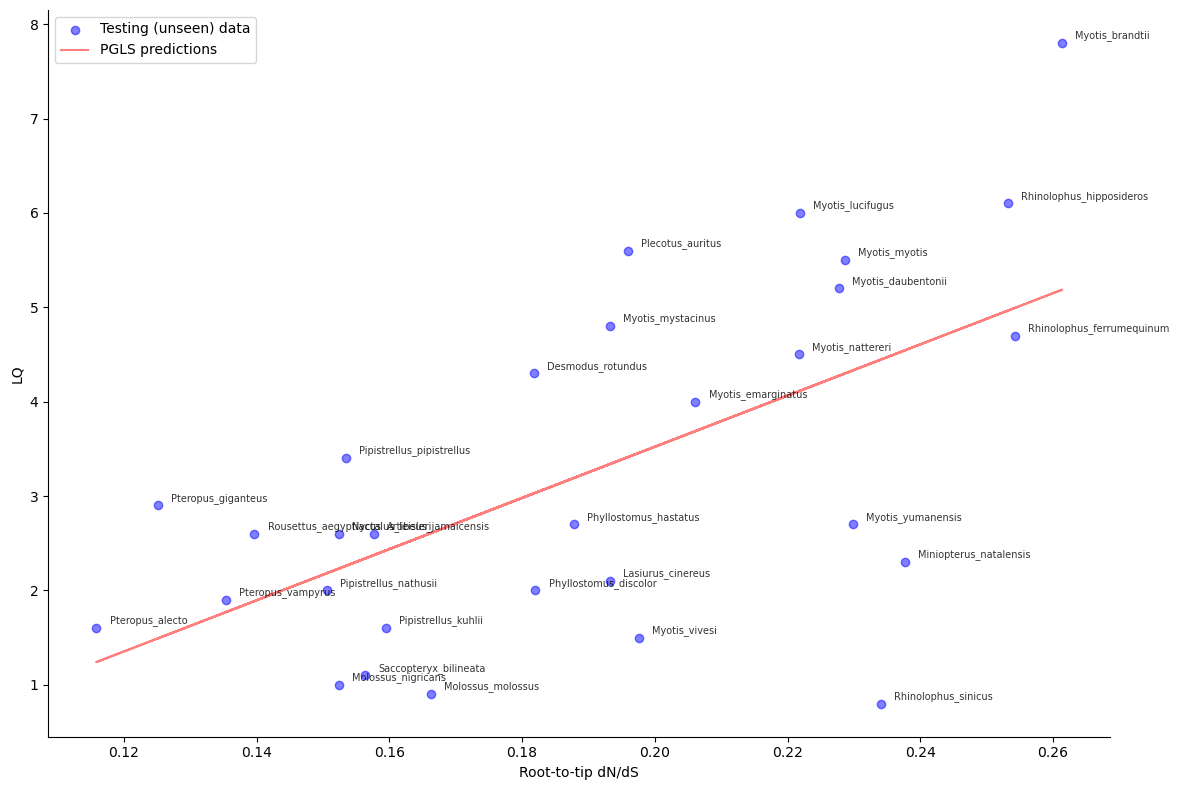

In [97]:
with open(data_file_spps) as f:
    species = [line.strip() for line in f]

X_train = X_uw_uc
y_train = y_uw_uc

# PGLS
pgls = PGLS(fit_intercept=True)
pgls.fit(X_train, y_train)
y_pred_pgls = pgls.predict(X_train)

plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(X_train, y_train , color = 'blue', alpha=0.5, label = 'Testing (unseen) data')
plt.plot(X_train, y_pred_pgls, color = 'red', alpha=0.5, label = 'PGLS predictions')
dx = 0.002   # оффсет чтоб не было оверлепа
dy = 0.05

# пришлось поставить, так как np версия тоже старая))
x_flat = np.asarray(X_train).ravel()
y_flat = np.asarray(y_train).ravel()

for i, sp in enumerate(species):
    plt.text(x_flat[i] + dx, y_flat[i] + dy, sp, fontsize=7, alpha=0.8)

plt.xlabel('Root-to-tip dN/dS')
plt.ylabel('LQ')
plt.legend()
plt.tight_layout()

In [98]:
r2_pgls = pgls.score(X_train, y_train, metric='r2')
rmse = pgls.score(X_train, y_train, metric ='rmse')

print(f"R2 for PGLS: {r2_pgls}")
print(f"RMSE for PGLS: {rmse}")

R2 for PGLS: 0.3703532951785342
RMSE for PGLS: 1.4297639609468296


Для одного гена очень интересный результат!

## Домашнее задание

### **Задание 1**
Проведите аналогичный анализ с генами CLEC14A и POLG. Объясните полученные результаты. Что могло пойти не так в случае с POLG?

*Всегда соблюдайте порядок видов для корректной работы PGLS*

In [76]:
import re

In [59]:
# busted-e сначала
# foreground
run_busted("./cba_comp_age_hw/CLEC14A_aln.fasta","./cba_comp_age_hw/CLEC14A_tree.nwk", "Foreground")
run_busted("./cba_comp_age_hw/POLG_aln.fasta","./cba_comp_age_hw/POLG_tree.nwk", "Foreground")

check_busted_results(path="results/CLEC14A_Foreground_res.json")
print()
check_busted_results(path="results/POLG_Foreground_res.json")


Done: ./results/CLEC14A_Foreground_res.json
Done: ./results/POLG_Foreground_res.json
LRT statistic: 6.6974
P-value: 0.01757
Unconstrained logL: -4799.3692
Constrained logL: -4802.7179
LRT statistic: 7.2718
P-value: 0.01318
Unconstrained logL: -10932.9877
Constrained logL: -10936.6236


In [60]:
# background
run_busted("./cba_comp_age_hw/CLEC14A_aln.fasta","./cba_comp_age_hw/CLEC14A_tree.nwk", "Background")
run_busted("./cba_comp_age_hw/POLG_aln.fasta","./cba_comp_age_hw/POLG_tree.nwk", "Background")


Done: ./results/CLEC14A_Background_res.json
Done: ./results/POLG_Background_res.json


In [63]:
check_busted_results(path="results/CLEC14A_Background_res.json")
print()
check_busted_results(path="results/POLG_Background_res.json")

LRT statistic: 0.1798
P-value: 0.457
Unconstrained logL: -4807.4325
Constrained logL: -4807.5224

LRT statistic: 0.0000
P-value: 0.5
Unconstrained logL: -10953.2583
Constrained logL: -10953.2727


In [61]:
# aBSREL
run_absrel("./cba_comp_age_hw/CLEC14A_aln.fasta", "./cba_comp_age_hw/CLEC14A_tree.nwk")
run_absrel("./cba_comp_age_hw/POLG_aln.fasta", "./cba_comp_age_hw/POLG_tree.nwk")

✅ Done: ./results/CLEC14A_absrel_res.json
✅ Done: ./results/POLG_absrel_res.json


In [62]:
check_absrel_results(path="results/CLEC14A_absrel_res.json")
print()
check_absrel_results(path="results/POLG_absrel_res.json")


Positive test results: 1.000000
Branches under episodic positive selection:

mlXP_006085874_2           p=0.00e+00  LRT=76.42  ω=345.63  prop=5.63%

Positive test results: 1.000000
Branches under episodic positive selection:

mbXP_014389040_1           p=0.00e+00  LRT=224.55  ω=4065.05  prop=8.35%


In [64]:
run_mg94("./cba_comp_age_hw/CLEC14A_aln.fasta", "./cba_comp_age_hw/CLEC14A_tree.nwk")
run_mg94("./cba_comp_age_hw/POLG_aln.fasta", "./cba_comp_age_hw/POLG_tree.nwk")

✅ Done: ./results/CLEC14A_mg94_res.json
✅ Done: ./results/POLG_mg94_res.json


In [68]:
def mg94_to_df(gene, results_dir="./results"):
    d = json.load(open(f"{results_dir}/{gene}_mg94_res.json"))["branch attributes"]["0"]
    df = pd.DataFrame(
        [{"node": k, "lineage_dNdS": v["Lineage dN/dS"]}
         for k, v in d.items() if "Lineage dN/dS" in v]
    )

    df.to_csv(f"{gene}_dnds.csv", index=False)
    return df


def add_species_lq(df, gene, ref=REF):
    code = df["node"].str[:2].str.lower()
    df["Species"] = code.map(lambda c: ref.get(c, {}).get("Species"))
    df["LQ"]      = code.map(lambda c: ref.get(c, {}).get("LQ"))
    df.to_csv(f"{gene}_dnds_LQ.csv", index=False)

    return df


MYOTIS = {"mb", "ml", "md", "mm", "me", "ma", "my"}

def myotis_boxplot(df, gene, myotis=MYOTIS):
    """Сравнение Myotis vs Other по lineage_dNdS: печать средних + boxplot"""
    df = df.copy()
    df["code"]  = df["node"].str[:2].str.lower()
    df["group"] = df["code"].isin(myotis).map({True: "Myotis", False: "Other"})

    print(df.groupby("group")["lineage_dNdS"].mean())

    plt.figure()
    plt.boxplot(
        [df.loc[df["group"] == "Myotis", "lineage_dNdS"],
         df.loc[df["group"] == "Other",  "lineage_dNdS"]],
        labels=["Myotis", "Other"],
        showmeans=False,
    )

    plt.ylabel("Lineage dN/dS")
    plt.title(f"{gene}: Lineage dN/dS — Myotis vs Others")
    plt.show()

    return df


def process_gene(gene):
    """Полный пайплайн для гена: CSV - Species/LQ - boxplot"""
    df = mg94_to_df(gene)
    df = add_species_lq(df, gene)
    myotis_boxplot(df, gene)

    return df


group
Myotis    0.527724
Other     0.474508
Name: lineage_dNdS, dtype: float64


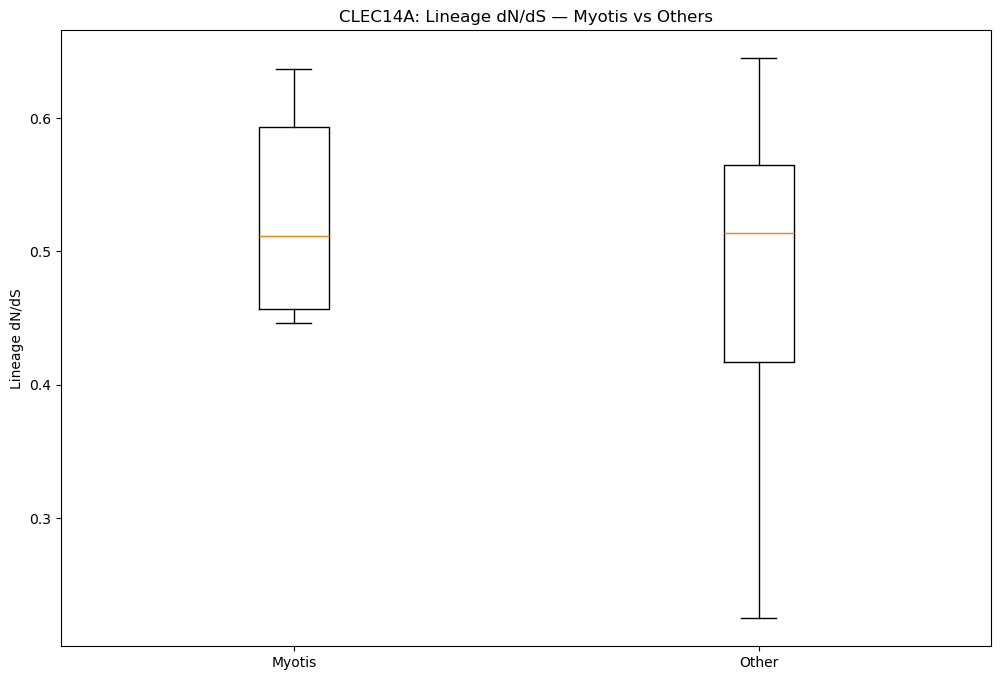

group
Myotis    0.093526
Other     0.093185
Name: lineage_dNdS, dtype: float64


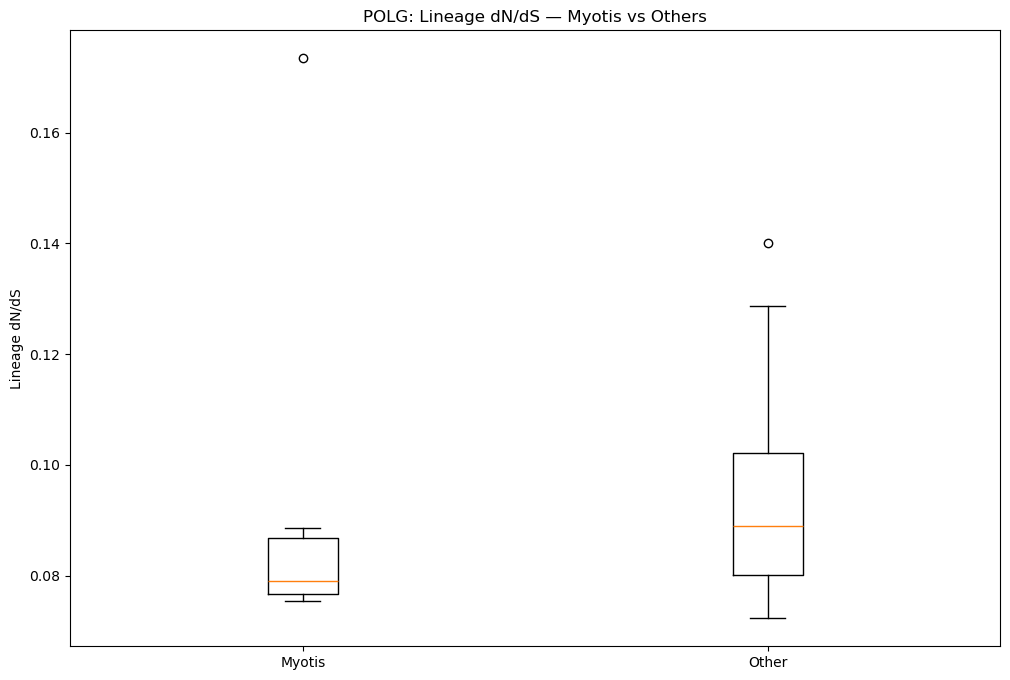

In [69]:
clec_df = process_gene("CLEC14A")
polg_df = process_gene("POLG")

In [ ]:
# вынес всё в одно место, чтобы не копипастить
TREE_FILE = "./cba_comp_age_hw/pgls_tree.txt"

def prep_pgls_files(gene):
    df = pd.read_csv(f"{gene}_dnds_LQ.csv")

    data_file = f"{gene}_pgls_data.csv"

    # признак (dN/dS) + таргет (LQ), без node/Species
    df.drop(["node", "Species"], axis=1).to_csv(data_file, index=False, header=False)

    return data_file


def run_pgls(gene, tree_file=TREE_FILE, show_plot=True):
    """Полный PGLS для одного гена: чтение -> fit -> график -> метрики"""
    data_file = prep_pgls_files(gene)

    X, y, vcv = read_data(
        tree_file,
        data_file,
        data_file_spps,
        y_col=1, # target та же вторая колонка (LQ) для 1 гена в моменте
        delimiter=',',
        verbose=False
    )

    with open(data_file_spps) as f:
        species = [line.strip() for line in f]

    # pgls
    pgls = PGLS(fit_intercept=True)
    pgls.fit(X, y)
    y_pred = pgls.predict(X)

    # расчёт ошибки и дисперсии
    r2 = pgls.score(X, y, metric='r2')
    rmse = pgls.score(X, y, metric='rmse')

    print(f"[{gene}] R2 = {r2:.4f} | RMSE = {rmse:.4f}")

    if show_plot:
        x_flat = np.asarray(X).ravel()
        y_flat = np.asarray(y).ravel()
        order  = np.argsort(x_flat)  # чтобы линия предсказаний была гладкой

        plt.figure(figsize=(12, 8))
        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.scatter(x_flat, y_flat, color='blue', alpha=0.5, label='Data')
        plt.plot(x_flat[order], np.asarray(y_pred).ravel()[order],
                 color='red', alpha=0.7, label='PGLS predictions')

        dx, dy = 0.002, 0.05
        for i, sp in enumerate(species):
            plt.text(x_flat[i] + dx, y_flat[i] + dy, sp, fontsize=7, alpha=0.8)

        plt.xlabel('Root-to-tip dN/dS')
        plt.ylabel('LQ')
        plt.title(f'PGLS: {gene}')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {"gene": gene, "model": pgls, "X": X, "y": y, "y_pred": y_pred, "species": species, "r2": r2, "rmse": rmse}


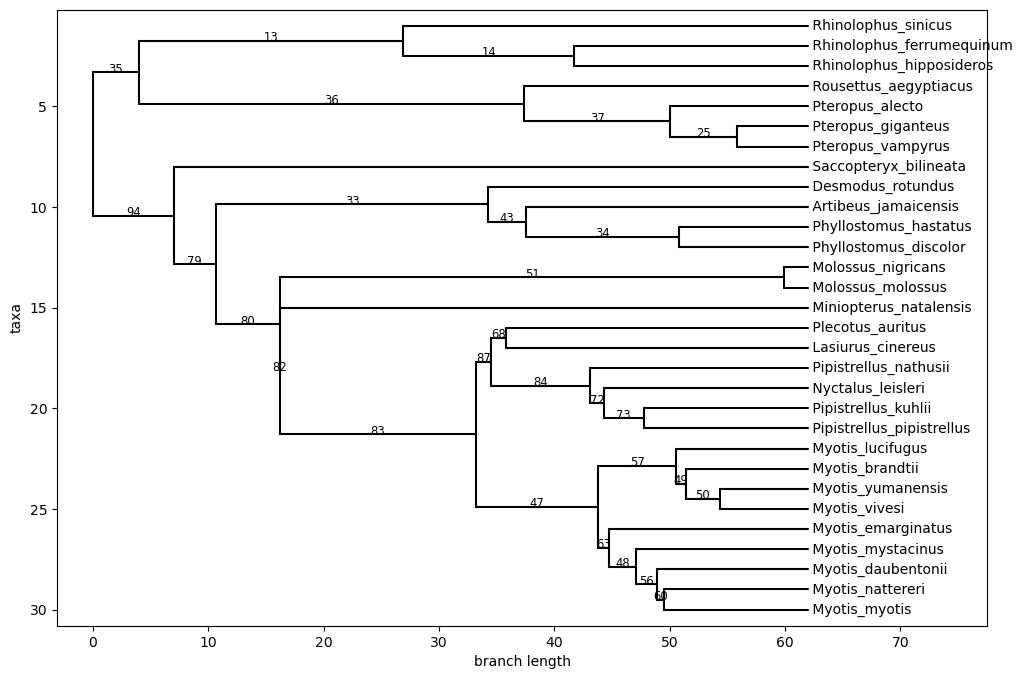

[CLEC14A] R2 = 0.1285 | RMSE = 1.6821


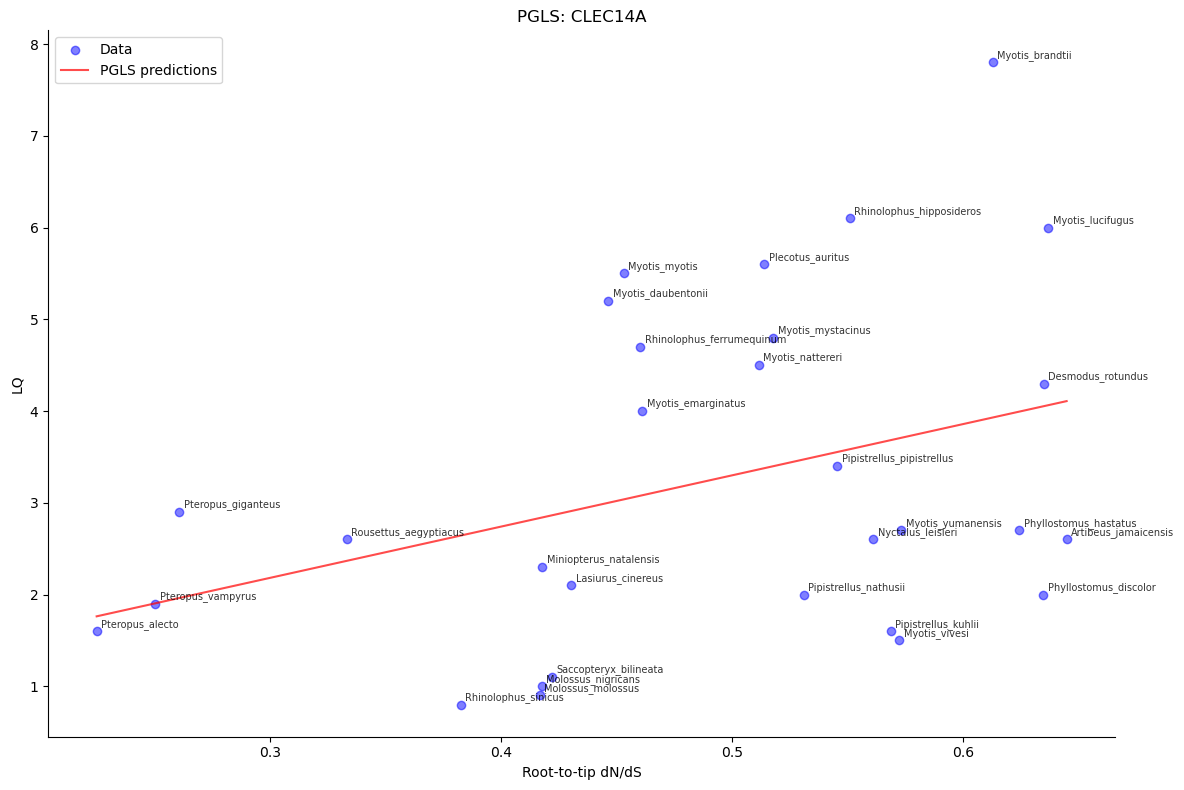

[POLG] R2 = 0.0563 | RMSE = 1.7504


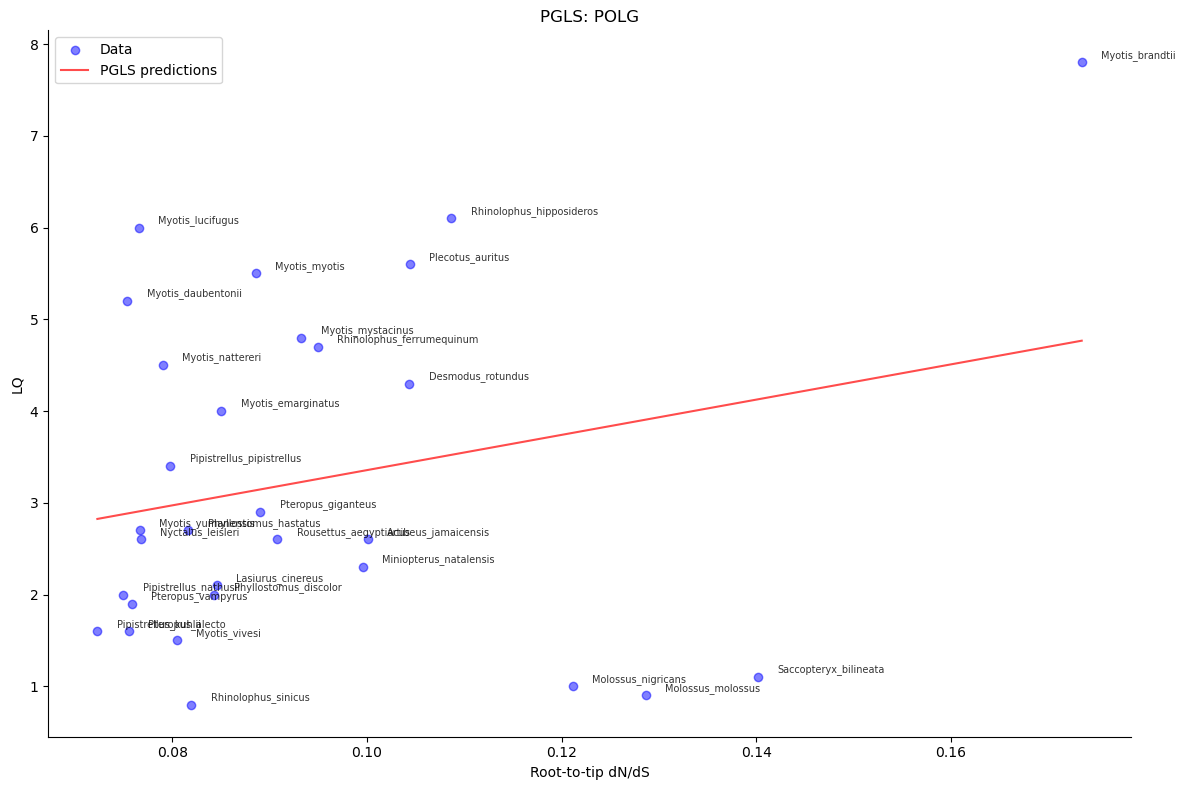

In [ ]:
# снова нарисуем дерево
tree = Phylo.read(tree_file, "newick")
tree.ladderize()
Phylo.draw(tree)

res = run_pgls("CLEC14A")
res = run_pgls("POLG")

#### Выводы

1. Foreground vs Background: во всех 3 генах был положительный отбор на Foreground (долгоживущих) и отсутствовал на Background (короткоживущих/среднеживущих). То есть сигнал отбора связан именно с долголетием, а не является общим свойством всей клады рукокрылых.

2. `CLEC14A` в 3 раза ниже по R2, значит там более слабая разница групп. В целом стандартный случай, скорее прошлый ген был завышенно влияющий. Скорее первый ген был переоценен.

3. `POLG` вообще близок к нулю. Всё дело в том, что там потенциально очень низок dS, это видно из запусков aBSREL выше (ω=4065.05), такие значения означают, что ds -> 0. Раз нет синономичных мутаций, то root-to-tip ω шумный, в итоге плохо регрессируется на LQ.

4. На филогенетических деревьях на foreground ветвях метки выше, то есть визуально на дереве тоже согласуется с BUSTED.

### **Задание 2**
Постройте multivariate PGLS модель на основе $\omega$ значений, получившихся для всех 3 генов. \
\
**Важно:** Если вам совсем не нравится phylokrr, то можете сделать это задание в R через caper.

In [104]:
GENES = ["mmp25", "CLEC14A", "POLG"]  #  3 прошлых рассматриваем

def prep_multivariate_files():
    dfs = []
    for g in GENES:
        d = pd.read_csv(f"{g}_dnds_LQ.csv")[["Species", "lineage_dNdS", "LQ"]]
        d = d.rename(columns={"lineage_dNdS": f"omega_{g}"})
        dfs.append(d)

    # merge по Species
    # LQ берём только из первого, у остальных дропаем
    merged = dfs[0]
    for d in dfs[1:]:
        merged = merged.merge(d.drop(columns="LQ"), on="Species", how="inner")

    # порядок столбцов: предикторы (3 omega) -> таргет (LQ)
    omega_cols = [f"omega_{g}" for g in GENES]
    merged = merged[["Species"] + omega_cols + ["LQ"]]

    data_file = "multi_pgls_data.csv"
    merged[omega_cols + ["LQ"]].to_csv(data_file, index=False, header=False)

    return data_file, merged


def run_multivariate_pgls(tree_file=TREE_FILE):
    data_file, merged = prep_multivariate_files()

    X, y, vcv = read_data(tree_file, data_file, data_file_spps, y_col=3, delimiter=',', verbose=False)

    pgls = PGLS(fit_intercept=True)
    pgls.fit(X, y)
    y_pred = pgls.predict(X)

    r2 = pgls.score(X, y, metric='r2')
    rmse = pgls.score(X, y, metric='rmse')
    print(f"[multivariate] R2 = {r2:.4f} | RMSE = {rmse:.4f}")

    # вклад каждого гена
    print("intercept:", pgls.intercept)
    beta = np.asarray(pgls.beta).ravel()
    for g, c in zip(GENES, beta):
        print(f"{g}: {c:.4f}")

    return {"model": pgls, "X": X, "y": y, "y_pred": y_pred, "merged": merged, "r2": r2, "rmse": rmse}


[multivariate] R2 = 0.4022 | RMSE = 1.3931
intercept: 0
mmp25: -3.2373
CLEC14A: 23.5640
POLG: 2.2579


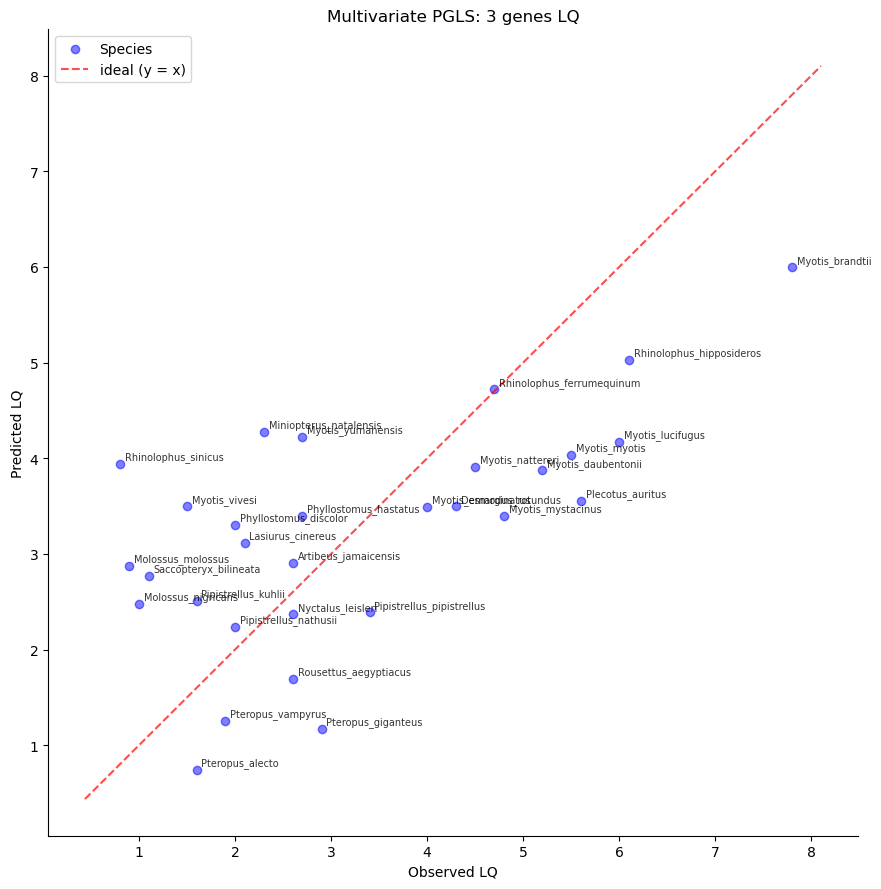

In [105]:
res_multi = run_multivariate_pgls()

y_true = np.asarray(res_multi["y"]).ravel()
y_hat = np.asarray(res_multi["y_pred"]).ravel()
sp = res_multi["merged"]["Species"].tolist()

plt.figure(figsize=(9, 9))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(y_true, y_hat, color='blue', alpha=0.5, label='Species')

lims = [min(y_true.min(), y_hat.min()) - 0.3, max(y_true.max(), y_hat.max()) + 0.3]
plt.plot(lims, lims, 'r--', alpha=0.7, label='ideal (y = x)')

for i, s in enumerate(sp):
    plt.text(y_true[i] + 0.05, y_hat[i] + 0.05, s, fontsize=7, alpha=0.8)

plt.xlabel('Observed LQ')
plt.ylabel('Predicted LQ')
plt.title('Multivariate PGLS: 3 genes LQ')
plt.legend()
plt.tight_layout()
plt.show()


#### Выводы

1. Учитывая, что каждый был хорошим foreground, вышло вкупе очень большое число R2 = 0.4022, выше первого значения. Оно логично, что накопилось за счёт того, что эти положительный отбор BUSTED Foreground показывали, а теперь тут их сразу 3 гена.

2. mmp25: -3.2373 стал отрицательным, до этого будучи сильнейшим, а CLEC14A наоборот сильно вырос. Это похоже на признак мультиколлинеарности генов (совместно растут на ветвях Myotis), поэтому веса нестабильно распределило.

3. Прирост умеренный (0.37 -> 0.40), а не кратный, как могло бы показаться логичным

### **Задание 3**
Напишите функцию, запускающую тул MEME, анализирующий сайты под действием положительного отбора. Проанализируйте все гены им и объясните полученные результаты.

In [89]:
def run_meme(align, tree, branches="Foreground"):
    os.makedirs("./results", exist_ok=True)
    gene = os.path.basename(align).split("_")[0]
    out_json = f"./results/{gene}_meme_res.json"
    log_file = f"./results/{gene}_meme_log.txt"

    cmd = [
        "hyphy", f"CPU={os.cpu_count()}", "meme",
        "--alignment", align,
        "--tree", tree,
        "--branches", branches,
        "--output", out_json,
    ]

    with open(log_file, "w") as log:
        subprocess.run(cmd, stdout=log, stderr=subprocess.STDOUT, check=False)
    print(f"Done: {out_json}")


# запуск по всем трём генам
for g in ["mmp25", "CLEC14A", "POLG"]:
    run_meme(f"./cba_comp_age_hw/{g}_aln.fasta", f"./cba_comp_age_hw/{g}_tree.nwk", "Foreground")


Done: ./results/mmp25_meme_res.json
Done: ./results/CLEC14A_meme_res.json
Done: ./results/POLG_meme_res.json


In [108]:
summary = []
for g in ["mmp25", "CLEC14A", "POLG"]:
    # BUSTED FG p-value
    with open(f"./results/{g}_Foreground_res.json") as f:
        busted_fg = json.load(f)["test results"]["p-value"]

    # MEME — число сайтов
    with open(f"./results/{g}_meme_res.json") as f:
        meme = json.load(f)["MLE"]["content"]["0"]

    p_idx = 6
    n_sites = sum(1 for r in meme if r[p_idx] <= 0.1)
    summary.append({"gene": g, "BUSTED_FG_p": busted_fg, "MEME_sites": n_sites, "MEME_total": len(meme), "MEME_p_0.1(%)": n_sites / len(meme) * 100})

pd.DataFrame(summary)

,gene,BUSTED_FG_p,MEME_sites,MEME_total,MEME_p_0.1(%)
0,mmp25,0.030713,12,496,2.419355
1,CLEC14A,0.017565,16,250,6.400000
2,POLG,0.013180,13,742,1.752022


In [112]:
def check_meme_results(path, p_thresh=0.1):
    with open(path) as f:
        data = json.load(f)

    headers = [h[0] for h in data["MLE"]["headers"]]
    rows = data["MLE"]["content"]["0"]
    i_alpha = 0
    i_bplus = headers.index("&beta;<sup>+</sup>")
    i_p = headers.index("p-value")
    i_nbr = headers.index("# branches under selection")
    gene = os.path.basename(path).split("_")[0]
    print(f"\nГен {gene}\n")

    for k, row in enumerate(rows):
        if row[i_p] <= p_thresh:
            a, bplus = row[i_alpha], row[i_bplus]
            omega = bplus / a if a > 1e-6 else float("inf")
            art = "dS=0" if a < 1e-3 else ""

            print(f"сайт {k+1}: p={row[i_p]:.4f}, ω+={omega:6.2f}, "
                  f"α={a:.4f}, ветвей={int(row[i_nbr])} {art}")

for g in ["mmp25", "CLEC14A", "POLG"]:
    check_meme_results(f"./results/{g}_meme_res.json")


Ген mmp25

сайт 47: p=0.0064, ω+=1075439.80, α=0.0000, ветвей=1 dS=0
сайт 115: p=0.0925, ω+= 26.54, α=5.0442, ветвей=1 
сайт 254: p=0.0890, ω+=738212.08, α=0.0000, ветвей=1 dS=0
сайт 259: p=0.0019, ω+=214183.54, α=0.0010, ветвей=1 dS=0
сайт 373: p=0.0036, ω+=3865.39, α=25.8706, ветвей=1 
сайт 385: p=0.0567, ω+=100.93, α=12.5008, ветвей=1 
сайт 396: p=0.0667, ω+=2275.52, α=0.0464, ветвей=1 
сайт 401: p=0.0720, ω+=106.11, α=18.3801, ветвей=1 
сайт 406: p=0.0657, ω+=2093.40, α=0.0420, ветвей=1 
сайт 407: p=0.0048, ω+=13403693.79, α=0.0005, ветвей=1 dS=0
сайт 408: p=0.0287, ω+=48098123.17, α=0.0000, ветвей=2 dS=0
сайт 490: p=0.0984, ω+=13844.57, α=0.0278, ветвей=1 

Ген CLEC14A

сайт 17: p=0.0008, ω+=591892.27, α=0.0000, ветвей=1 dS=0
сайт 71: p=0.0095, ω+=37131.99, α=0.0054, ветвей=3 
сайт 151: p=0.0528, ω+=204805.66, α=0.0001, ветвей=1 dS=0
сайт 152: p=0.0116, ω+=63091.10, α=0.0005, ветвей=3 dS=0
сайт 155: p=0.0018, ω+=694121.32, α=0.0001, ветвей=1 dS=0
сайт 157: p=0.0000, ω+=1081272.92

#### Выводы MEME

MEME ищет отдельные кодоны под эпизодическим положительным отбором.

1. CLEC14A показывает наибольшую плотность отбора (6.4% сайтов) с очень сильными p-value (сайт 157: p<0.0001) и кластерами соседних сайтов (151-157, 197-204, 237-249). Отбор сконцентрирован в конкретных участках белка — вероятно, функционально важных доменах. Согласуется со значимым BUSTED на Foreground (p=0.018).

2. MMP25: 12 сайтов (2.4%), Наиболее достоверные — с ненулевой α: 373 (p=0.0036, α=25.9), 385, 401. Умеренный чёткий сигнал.

3. POLG: 13 сайтов (1.8%) — наименьшая плотность отбора из трёх генов. Как и у остальных, значимость части сайтов опирается на α≈0 (см. п. 4–5), поэтому буквальная локализация ненадёжна. Это согласуется с тем, что POLG — консервативная митохондриальная полимераза под сильным очищающим отбором (тот же эффект малого dS дал ω=4065 в aBSREL).

4. Большинство сайтов под отбором — лишь на 1 ветви (эпизодический отбор на одной линии). При α почти 0 такие сайты особенно склонны к ложным срабатываниям. Но есть и более надёжны сайты с ненулевой α и/или отбором на нескольких ветвях:

   - CLEC14A: сайты 71, 152, 244 (по 3 ветви) — наиболее достоверны;
   - POLG: сайт 102 (2 ветви, α=15.1) — единственный «крепкий» сигнал;
   - MMP25: сайты 115, 373, 385, 401 (биологически правдоподобная α).

5. Колонка ω+ не интерпретируется как сила отбора. Значения ω+ = 10^5-10^7 нереалистичны и возникают из-за оценки синонимичной скорости α≈0 (деление β+ на почти ноль). Примерно половина значимых сайтов в КАЖДОМ гене имеет α≈0. MEME тестирует через LRT/p-value, а не через саму ω+, поэтому значимость валидна, саму величину ω+ в таких кейсах нужно игнорировать.


### И я решил накидать общий вывод

Четыре метода описывают один сигнал на разных уровнях:

- BUSTED: положительный отбор значим на ветвях долгожителей (Foreground) во всех трёх генах и отсутствует на фоне (Background) — отбор связан именно с долголетием.

- aBSREL: локализует отбор в конкретные ветви (клад Myotis).

- MEME: локализует отбор в конкретные сайты, но с оговоркой про сатурацию dS (ω+ ненадёжна; надёжны сайты с ненулевой α / >1 ветви).

- PGLS: связывает root-to-tip dN/dS с LQ: одиночно сильнее всего для MMP25 (R2=0.37), мультивариантная модель трёх генов даёт лучший результат (R2=0.40).

Общее ограничение ω-методов — сатурация синонимичной скорости в консервативных позициях/генах: при dS близкой к 0 оценки ω взрываются и требуют осторожной трактовки.
